## Mapping Rivers and Wetlands in Iceland using Sentinel-2 MNDWI

<a href="https://jupyterhub.user.eopf.eodc.eu/hub/user-redirect/git-pull?repo=https://github.com/eopf-toolkit/eopf-101&branch=main&urlpath=lab/tree/eopf-101/sentinel2_water_mapping.ipynb" target="_blank">
  <button style="background-color:#0072ce; color:white; padding:0.6em 1.2em; font-size:1rem; border:none; border-radius:6px; margin-top:1em;">
    🚀 Launch this notebook in JupyterLab
  </button>
</a>

### Introduction

In this tutorial, we'll map water bodies and wetlands in Iceland using satellite imagery from Sentinel-2. Iceland's unique landscape features glacial rivers, wetlands making it an excellent location to demonstrate water detection techniques.

We'll use the Modified Normalized Difference Water Index (MNDWI), which helps identify water by comparing how different wavelengths of light reflect off water surfaces. Our analysis covers a scene from May 2025 over Iceland region.

### What we will learn

- 🛰️ Access Sentinel-2 L2A imagery through the EOPF STAC Catalog in cloud-optimized Zarr format.
- ⚙️ Preprocess multispectral bands with scale/offset transformations and cloud masking using scene classification.
- 💧 Calculate the Modified Normalized Difference Water Index (MNDWI) to identify water features.
- 🗺️ Classify water bodies based on MNDWI intensity thresholds to distinguish rivers from wetlands.
- 🎨 Visualize water features using true color, false color, and classification maps.

### Prerequisites

You should be familiar with basic Python, NumPy-style array processing, and geospatial data concepts.
This tutorial uses xarray, pystac-client, zarr, and common plotting libraries using matplotlib.

<hr>

#### Import libraries

In [3]:
import xarray as xr
import zarr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import fsspec
from pystac_client import Client as StacClient
from scipy.ndimage import zoom
import time

<hr>

## Section 1: Data Preparation

In [ ]:
# Connect to EOPF STAC Catalog
eopf_stac_api_root_endpoint = "https://stac.core.eopf.eodc.eu/"
eopf_catalog = StacClient.open(url=eopf_stac_api_root_endpoint)

# Load the scene
SCENE_ID = "S2B_MSIL2A_20250518T130259_N0511_R038_T28WDT_20250518T150319"
selected_item = eopf_catalog.get_collection("sentinel-2-l2a").get_item(SCENE_ID)

print(f"Loaded scene: {SCENE_ID}")

Loaded scene: S2B_MSIL2A_20250518T130259_N0511_R038_T28WDT_20250518T150319


<hr>

#### Helper Functions

Helper functions to load satellite data, clean it, and calculate the water index.

In [5]:
def get_zarr_urls_from_item(item):
    """
    Extract Zarr URLs from a STAC item
    
    Args:
        item: STAC item
    
    Returns:
        Dictionary with Zarr URLs for different resolutions
    """
    assets = item.assets
    
    # Extract the base Zarr URL from one of the assets
    base_zarr_url = None
    for asset_key, asset in assets.items():
        if 'zarr' in asset.href.lower():
            # Extract base URL (everything before the asset-specific path)
            base_zarr_url = asset.href.split('/measurements')[0].split('/conditions')[0]
            break
    
    if not base_zarr_url:
        raise ValueError("No Zarr URL found in STAC item")
    
    return {
        'sr_10m': f"{base_zarr_url}/measurements/reflectance/r10m",
        'sr_20m': f"{base_zarr_url}/measurements/reflectance/r20m",
        'scl_20m': f"{base_zarr_url}/conditions/mask/l2a_classification/r20m/scl",
        'base': base_zarr_url
    }

In [6]:
def load_band(url, subset=None, max_retries=3, retry_delay=5):
    for attempt in range(max_retries):
        try:
            mapper = fsspec.get_mapper(url)
            z_array = zarr.open_array(mapper, mode='r')
            
            if subset:
                y_start, y_end, x_start, x_end = subset
                data = z_array[y_start:y_end, x_start:x_end]
            else:
                data = z_array[:]
            
            return xr.DataArray(data, dims=['y', 'x'])
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            else:
                raise Exception(f"Failed to load {url.split('/')[-1]} after {max_retries} attempts: {e}")


def load_band_from_group(group_url, band_name, subset=None, max_retries=3, retry_delay=5):
    for attempt in range(max_retries):
        try:
            mapper = fsspec.get_mapper(group_url)
            z_group = zarr.open_group(mapper, mode='r')
            z_array = z_group[band_name.lower()]
            
            if subset:
                y_start, y_end, x_start, x_end = subset
                data = z_array[y_start:y_end, x_start:x_end]
            else:
                data = z_array[:]
            
            return xr.DataArray(data, dims=['y', 'x'])
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            else:
                raise Exception(f"Failed to load {band_name} after {max_retries} attempts: {e}")


def apply_scale_offset(data, scale=0.0001, offset=-0.1):
    return data * scale + offset


def cloud_mask_scl(scl_data):
    clear_mask = ((scl_data == 4) | (scl_data == 5) | 
                  (scl_data == 6) | (scl_data == 7))
    return clear_mask


def resample_to_10m(data_20m, reference_10m):
    zoom_factor = reference_10m.shape[0] / data_20m.shape[0]
    resampled = zoom(data_20m.values, zoom_factor, order=1)
    return xr.DataArray(resampled, dims=['y', 'x'])


def calculate_mndwi(green, swir1):
    mndwi = (green - swir1) / (green + swir1)
    return mndwi

### Extract Zarr URLs

Select the scene from search results and extract Zarr URLs for each spectral band group.

In [ ]:
# Zarr URLs from the scene
zarr_urls = get_zarr_urls_from_item(selected_item)
sr_10m_url = zarr_urls['sr_10m']
sr_20m_url = zarr_urls['sr_20m']
scl_20m_url = zarr_urls['scl_20m']

# scene metadata for later visualization
scene_id = selected_item.id
scene_date = selected_item.properties.get('datetime', 'Unknown')
scene_cloud_cover = selected_item.properties.get('eo:cloud_cover', 'N/A')
scene_platform = selected_item.properties.get('platform', 'Sentinel-2')

### Configure Spatial Subset

Use a subset (3000×3000 pixels = 30×30 km) to reduce processing time and avoid gateway timeouts. Full scene size is 10980×10980 pixels (110×110 km).

In [ ]:
# subset configuration
USE_SUBSET = True
SUBSET_10m = (2000, 5000, 2000, 5000)  # 3000 x 3000 pixels at 10m resolution
SUBSET_20m = (1000, 2500, 1000, 2500)  # Corresponding 20m subset

### Load Sentinel-2 Bands

Load required bands:
- **10m resolution:** B02 (Blue), B03 (Green), B04 (Red), B08 (NIR)
- **20m resolution:** B11 (SWIR1), SCL (Scene Classification Layer)

In [11]:
# Load bands from Zarr
blue = load_band(sr_10m_url + '/b02', SUBSET_10m if USE_SUBSET else None)
green = load_band(sr_10m_url + '/b03', SUBSET_10m if USE_SUBSET else None)
red = load_band(sr_10m_url + '/b04', SUBSET_10m if USE_SUBSET else None)
nir = load_band(sr_10m_url + '/b08', SUBSET_10m if USE_SUBSET else None)
swir1 = load_band(sr_20m_url + '/b11', SUBSET_20m if USE_SUBSET else None)
scl = load_band(scl_20m_url, SUBSET_20m if USE_SUBSET else None)

In [12]:
print(f"10m resolution bands: {blue.shape}")
print(f"20m resolution bands: {swir1.shape}")

10m resolution bands: (3000, 3000)
20m resolution bands: (1500, 1500)


### Apply Preprocessing Corrections

Convert digital numbers to surface reflectance using scale (0.0001) and offset (-0.1).

In [13]:
blue_ref = apply_scale_offset(blue)
green_ref = apply_scale_offset(green)
red_ref = apply_scale_offset(red)
nir_ref = apply_scale_offset(nir)
swir1_ref = apply_scale_offset(swir1)

<hr>

## Section 2: Water Index Computation

### Cloud Masking

Apply Scene Classification Layer (SCL) to mask clouds, shadows, and snow/ice. Retain only clear observations (SCL classes 4-7: vegetation, non-vegetated, water, unclassified).

In [14]:
cloud_mask_20m = cloud_mask_scl(scl)
cloud_mask_10m = resample_to_10m(cloud_mask_20m.astype(float), green)
cloud_mask_10m = cloud_mask_10m > 0.5

### Resample SWIR1 to 10m Resolution

Resample SWIR1 from 20m to 10m resolution using bilinear interpolation to match the green band.

In [15]:
swir1_10m = resample_to_10m(swir1_ref, green_ref)

###  Compute MNDWI

Calculate Modified Normalized Difference Water Index:

$$MNDWI = \frac{Green - SWIR1}{Green + SWIR1}$$

**Interpretation:**
- **> 0.4:** Permanent water (rivers, lakes)
- **0 to 0.4:** Seasonal water (wetlands)
- **< 0:** Non-water features

In [16]:
mndwi = calculate_mndwi(green_ref, swir1_10m)
mndwi_masked = mndwi.where(cloud_mask_10m)

### Classify Water Bodies

Apply thresholds to classify permanent (> 0.4) and seasonal (0 to 0.4) water bodies.

In [17]:
permanent_water = mndwi_masked > 0.4
seasonal_water = (mndwi_masked > 0) & (mndwi_masked <= 0.4)

# Calculate areal statistics
total_pixels = cloud_mask_10m.sum().values
permanent_pixels = (permanent_water & cloud_mask_10m).sum().values
seasonal_pixels = (seasonal_water & cloud_mask_10m).sum().values

pixel_area_m2 = 10 * 10
permanent_area_km2 = (permanent_pixels * pixel_area_m2) / 1e6
seasonal_area_km2 = (seasonal_pixels * pixel_area_m2) / 1e6

In [18]:
print(f"Permanent water (rivers, lakes): {permanent_area_km2:.2f} km²")
print(f"Seasonal water (wetlands):       {seasonal_area_km2:.2f} km²")
print(f"Total water extent:              {permanent_area_km2 + seasonal_area_km2:.2f} km²")
print(f"\nClear pixels analyzed: {total_pixels:,}")

Permanent water (rivers, lakes): 5.64 km²
Seasonal water (wetlands):       35.12 km²
Total water extent:              40.76 km²

Clear pixels analyzed: 8,491,983


<hr>

## Section 3: Visualization and Results

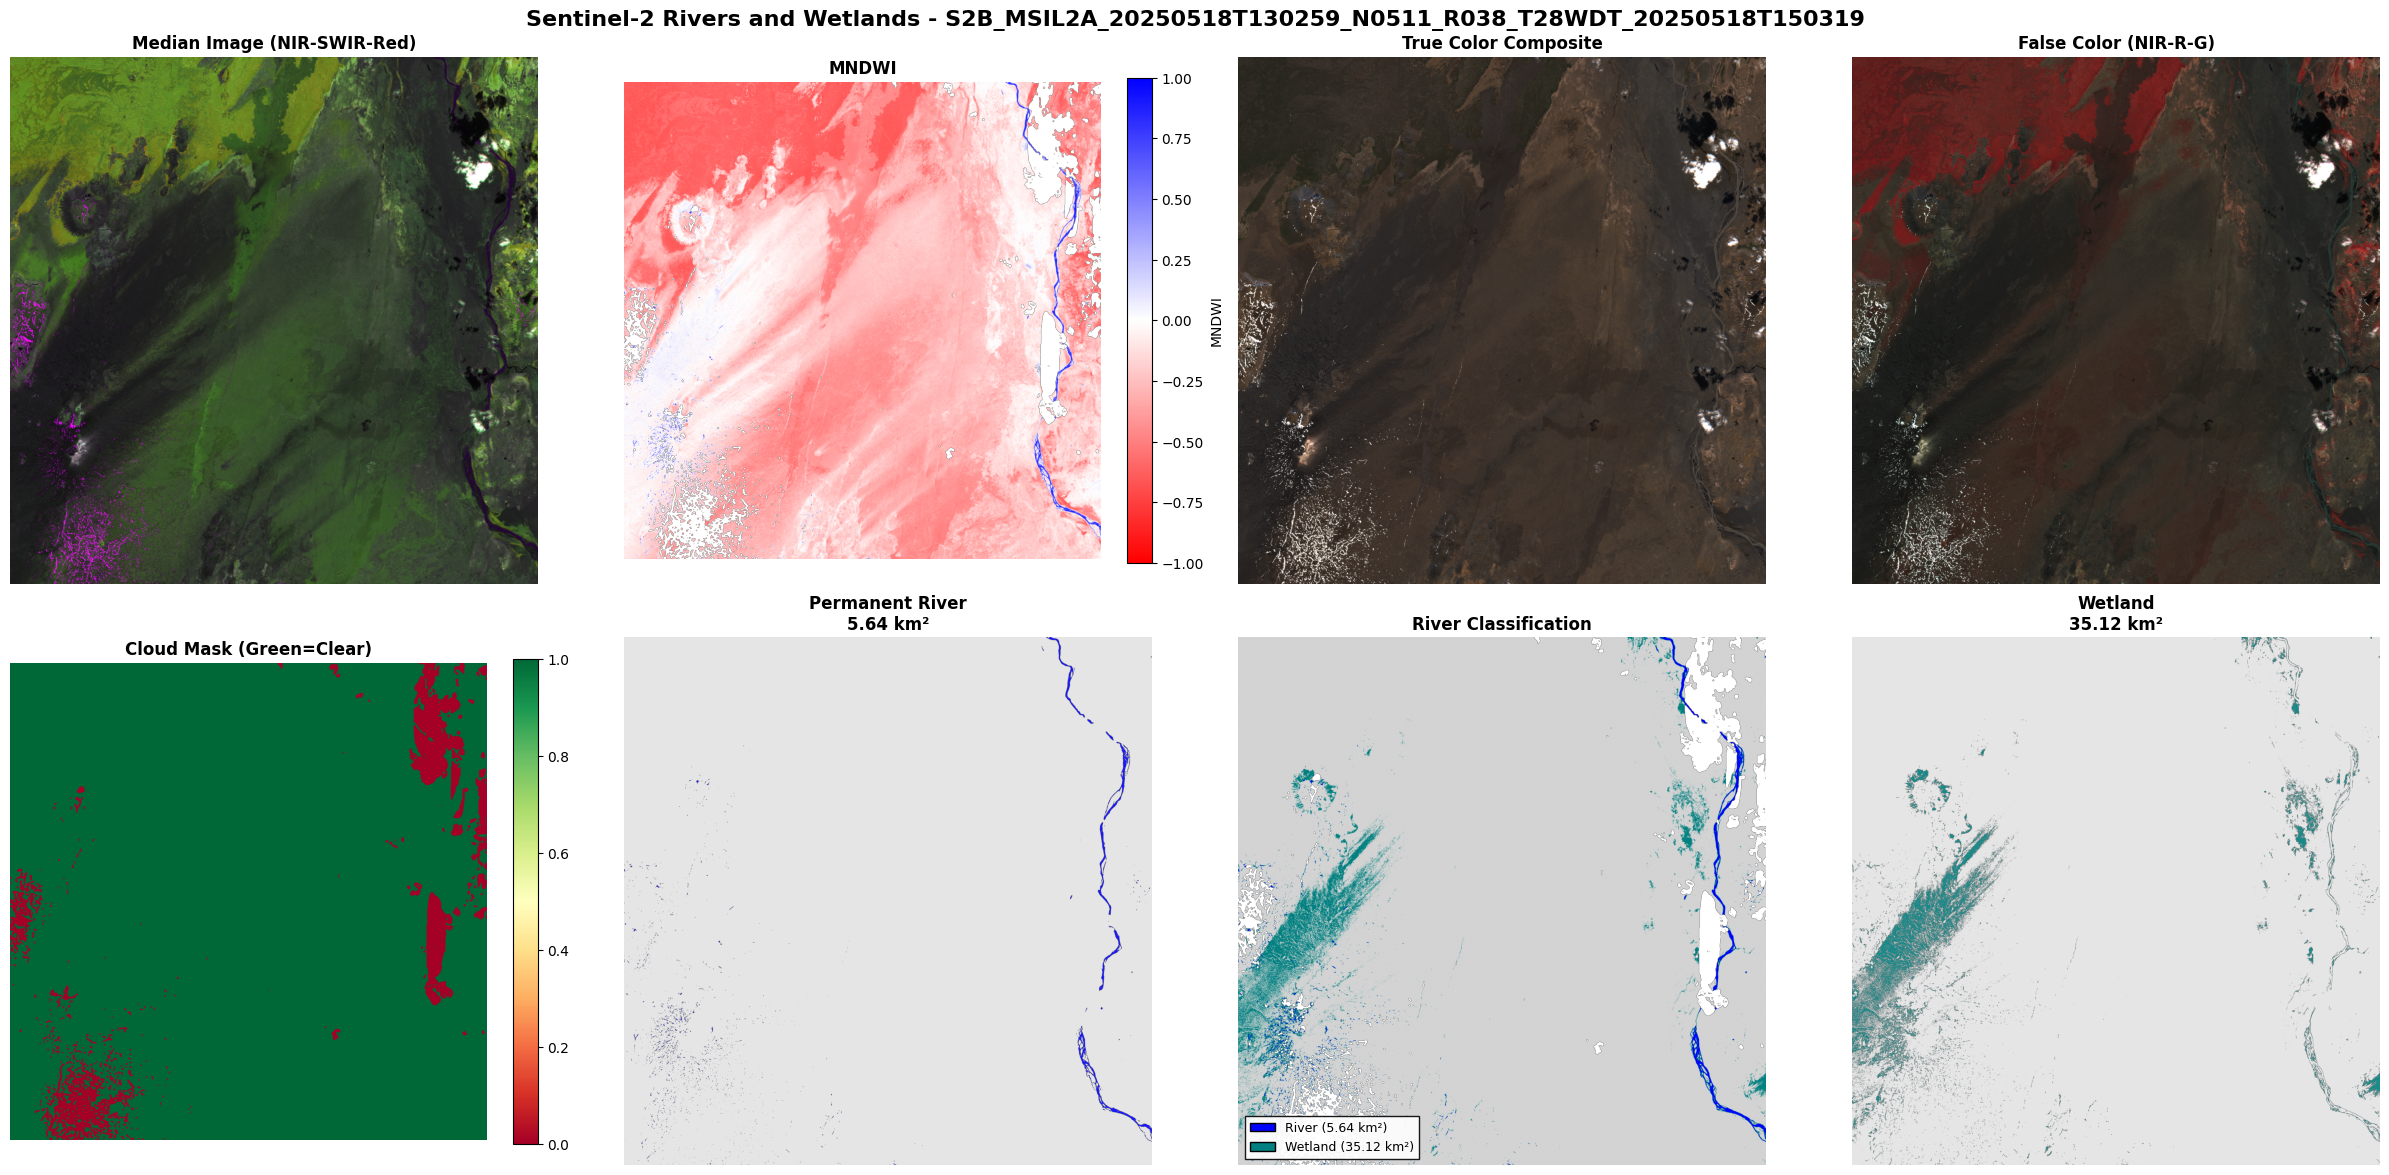

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

# Median Image (NIR-SWIR-Red)
rgb_median = np.stack([
    np.clip(nir_ref.values * 2.5, 0, 1),      # NIR (B08) -> Red channel
    np.clip(swir1_10m.values * 2.5, 0, 1),    # SWIR1 (B11) resampled to 10m -> Green channel
    np.clip(red_ref.values * 2.5, 0, 1)       # Red (B04) -> Blue channel
], axis=0)
axes[0, 0].imshow(rgb_median.transpose(1, 2, 0))
axes[0, 0].set_title('Median Image (NIR-SWIR-Red)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# 2. MNDWI - Red-White-Blue color palette
cmap_rwb = LinearSegmentedColormap.from_list('rwb', ['red', 'white', 'blue'])
im2 = axes[0, 1].imshow(mndwi_masked.values, cmap=cmap_rwb, vmin=-1, vmax=1)
axes[0, 1].set_title('MNDWI', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[0, 1], fraction=0.046, label='MNDWI')

# True Color Composite (RGB)
rgb = np.stack([
    np.clip(red_ref.values * 3.5, 0, 1),
    np.clip(green_ref.values * 3.5, 0, 1),
    np.clip(blue_ref.values * 3.5, 0, 1)
], axis=0)
axes[0, 2].imshow(rgb.transpose(1, 2, 0))
axes[0, 2].set_title('True Color Composite', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# False Color (NIR-Red-Green)
false_color = np.stack([
    np.clip(nir_ref.values * 2.5, 0, 1),
    np.clip(red_ref.values * 2.5, 0, 1),
    np.clip(green_ref.values * 2.5, 0, 1)
], axis=0)
axes[0, 3].imshow(false_color.transpose(1, 2, 0))
axes[0, 3].set_title('False Color (NIR-R-G)', fontsize=12, fontweight='bold')
axes[0, 3].axis('off')

# Cloud Mask
im3 = axes[1, 0].imshow(cloud_mask_10m.values, cmap='RdYlGn', vmin=0, vmax=1)
axes[1, 0].set_title('Cloud Mask (Green=Clear)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

# Permanent River 
permanent_masked = np.ma.masked_where(~permanent_water.values, permanent_water.values)
background_rgb = np.ones((permanent_water.shape[0], permanent_water.shape[1], 3)) * 0.9
axes[1, 1].imshow(background_rgb)
cmap_river = ListedColormap(['blue'])
im5 = axes[1, 1].imshow(permanent_masked, cmap=cmap_river, vmin=0, vmax=1, alpha=0.9)
axes[1, 1].set_title(f'Permanent River\n{permanent_area_km2:.2f} km²', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

# Water Classification - Combined view with legend
water_class = np.zeros_like(mndwi_masked.values)
water_class[permanent_water.values] = 2  # Rivers
water_class[seasonal_water.values] = 1  # Wetlands
water_class[~cloud_mask_10m.values] = np.nan  # Mask clouds

cmap_combined = ListedColormap(['lightgray', 'teal', 'blue'])
norm = BoundaryNorm([0, 0.5, 1.5, 2.5], cmap_combined.N)
im6 = axes[1, 2].imshow(water_class, cmap=cmap_combined, norm=norm)
axes[1, 2].set_title('River Classification', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label=f'River ({permanent_area_km2:.2f} km²)'),
    Patch(facecolor='teal', edgecolor='black', label=f'Wetland ({seasonal_area_km2:.2f} km²)')
]
legend = axes[1, 2].legend(handles=legend_elements, loc='lower left', 
                          fontsize=9, frameon=True, fancybox=False, shadow=False,
                          framealpha=0.9, edgecolor='black')

# Wetland 
wetland_masked = np.ma.masked_where(~seasonal_water.values, seasonal_water.values)
background_rgb_wetland = np.ones((seasonal_water.shape[0], seasonal_water.shape[1], 3)) * 0.9
axes[1, 3].imshow(background_rgb_wetland)
cmap = ListedColormap(['teal'])
axes[1, 3].imshow(wetland_masked, cmap=cmap, vmin=0, vmax=1, alpha=0.9)
axes[1, 3].set_title(f'Wetland\n{seasonal_area_km2:.2f} km²', 
                     fontsize=12, fontweight='bold')
axes[1, 3].axis('off')
plt.suptitle(f'Sentinel-2 Rivers and Wetlands - {scene_id}', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout();

<hr>

## Conclusion

This notebook demonstrated a complete workflow for river and wetland mapping using the Modified Normalized Difference Water Index (MNDWI) from Sentinel-2 L2A data accessed via the EOPF STAC Catalog. By accessing multispectral imagery through cloud-optimized Zarr format, preprocessing them with scale/offset corrections and cloud masking, and computing MNDWI, we successfully classified water bodies categories.

The workflow provides a practical example of using Sentinel-2 multispectral imagery for automated inland water and wetland detection. The Zarr format offers significant advantages for this type of analysis, enabling fast and scalable access to satellite imagery directly from cloud storage using standard Python libraries.